<a href="https://colab.research.google.com/github/dhag/colab_demo/blob/main/UDP_image_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UDP 体験デモ — 画像を1データグラムで送受信（トンネル不要）

このノートブックは **同一ランタイム内**で UDP の送信側・受信側を動かし、画像を送って体験する教材です。
外部公開（ngrok 等のトンネル）は不要で、`127.0.0.1`（localhost）上で本物の UDP ソケットを使います。

## UDP の要点
- **コネクションレス**：ハンドシェイクなし。相手の存在を確認せず「送りっぱなし」。
- **データグラム単位**：`sendto` 1回 = `recvfrom` 1回。TCP のようにストリーム結合しない。
- **非信頼**：再送・順序保証なし。落ちたら落ちたまま。

## サイズの上限について（重要）
よく「64K まで」と言いますが、実際の上限は **65507 バイト**です。
IPv4 の全長フィールドは16ビット = 最大 65535B。そこから IP ヘッダ20B と UDP ヘッダ8B を引くので、
1つの UDP データグラムに載せられるペイロードは最大 **65535 − 20 − 8 = 65507B**。
これを超えて `sendto` すると OS が `OSError (EMSGSIZE)` で弾くため、**送信前にサイズ判定して止めます**。

> 実行順：セル①（受信起動）→ セル②（送信関数）→ セル③（画像アップして送信）。表示が出ないときはセル④。

## ① 受信側（サーバ）を起動
バックグラウンドスレッド（隠れて実行を続ける。見えない）で待ち受けます。届いた画像は `received.png` に保存し、自動表示も試みます。

In [ ]:
import socket, threading, datetime
from IPython.display import Image, display

HOST, PORT = "0.0.0.0", 50007
rx = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)   # SOCK_DGRAM = UDP
rx.bind((HOST, PORT))
print(f"UDP listening on {HOST}:{PORT}")

def receiver():
    while True:
        data, addr = rx.recvfrom(65535)            # バッファは上限65535で確保
        ts = datetime.datetime.now().strftime("%H:%M:%S.%f")[:-3]
        print(f"[{ts}] received {len(data)}B from {addr[0]}:{addr[1]}")
        with open("received.png", "wb") as f:      # 確実に残す
            f.write(data)
        try:
            display(Image(data=data))              # 自動表示（出ない場合はセル④で表示）
        except Exception as e:
            print("（自動表示できず。セル④でreceived.pngを表示してください）", e)

threading.Thread(target=receiver, daemon=True).start()

UDP listening on 0.0.0.0:50007


動作確認。自分宛てに1発打って受信を確認。直後に受信側の received ...の行が出れば、スレッド・ソケット・受信処理すべて生きています。出なければスレッドが落ちています。

---



In [ ]:
import socket
test = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
test.sendto(b"selftest", ("127.0.0.1", 50007))

[07:36:45.963] received 8B from 127.0.0.1:53619


8

## ② 送信関数（サイズ判定つき）
65507B を超える画像は送信せず、理由を表示します。

In [ ]:
import socket

LIMIT  = 65507                          # IPv4 UDP ペイロード上限
TARGET = ("127.0.0.1", 50007)
tx = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)

def send_image(data: bytes, name="image"):
    n = len(data)
    if n > LIMIT:
        print(f"✗ {name}: {n}B > 上限{LIMIT}B → 1データグラムに収まらないので送信しません")
        return False
    tx.sendto(data, TARGET)             # 画像まるごと1データグラム
    print(f"✓ {name}: {n}B 送信（余裕 {LIMIT - n}B）")
    return True

## ③ 画像をアップロードして送信
ファイル選択ダイアログが出ます。複数選択可。小さめ（数十KB）の画像を用意してください。

送信に成功したら、画像が表示されます。

Saving タイトルなしA.png to タイトルなしA (2).png
✓ タイトルなしA (2).png: 49966B 送信（余裕 15541B）
[07:47:30.084] received 49966B from 127.0.0.1:33392


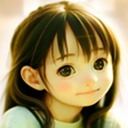

In [ ]:
from google.colab import files
up = files.upload()
for name, data in up.items():
    send_image(data, name)

## ④ 受信画像の表示（保険）
自動表示が出なかったときに実行してください。

送信に成功していれば、受信側で保存したファイルが表示されます。

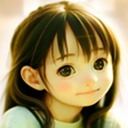

In [ ]:
from IPython.display import Image
Image("received.png")

## ⑤（おまけ）上限超えで「送らない」ことを確認
ランダムノイズ画像は PNG 圧縮が効かず巨大化します。`✗` になり送信されないことを確認できます。

In [ ]:
from PIL import Image as PImage
import io, random

img = PImage.new("RGB", (1500, 1500))
px = img.load()
for y in range(1500):
    for x in range(1500):
        px[x, y] = (random.randint(0, 255),) * 3      # ランダム = 圧縮が効かず巨大化
buf = io.BytesIO(); img.save(buf, "PNG"); big = buf.getvalue()
print("生成サイズ:", len(big), "B")
send_image(big, "oversized.png")                      # → ✗ で送信されないはず

生成サイズ: 5751041 B
✗ oversized.png: 5751041B > 上限65507B → 1データグラムに収まらないので送信しません


False

UDPポートを閉じる

In [ ]:
rx.close()

再度受信側の動作を確認。エラーが出れば止まっている。

In [ ]:
import socket
test = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
test.sendto(b"selftest", ("127.0.0.1", 50007))

[07:51:06.372] received 8B from 127.0.0.1:44420


8

Exception in thread Thread-6 (receiver):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/tmp/ipykernel_4642/2816465656.py", line 11, in receiver
OSError: [Errno 9] Bad file descriptor


---
### 補足（授業用メモ）
- 65507B 近い大きな画像が送れた場合でも、線の上では MTU（≈1500B）ごとに **IP フラグメント**へ分割されて飛ぶ。UDP は再送しないので、**分割片が1つでも欠ければデータグラム全体が破棄**され受信側には何も届かない（=「大きい UDP は届きにくい」理由）。
- これを見せるなら、64K 近い画像と数百バイトの画像で到達率を比べる展開が効く。
- 大きい画像を実用的に送るには、アプリ側で複数データグラムに分割＋シーケンス番号を付けて受信側で再構成する「自前フラグメンテーション」が次のステップ。